<a href="https://colab.research.google.com/github/Narware-Ayush/AI_ML/blob/main/ANN7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [26]:
torch.manual_seed(42)
df=pd.read_csv('/content/fmnist_small.csv')
df.head()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [27]:
df.info()
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device : {device}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 35.9 MB
Using Device : cuda


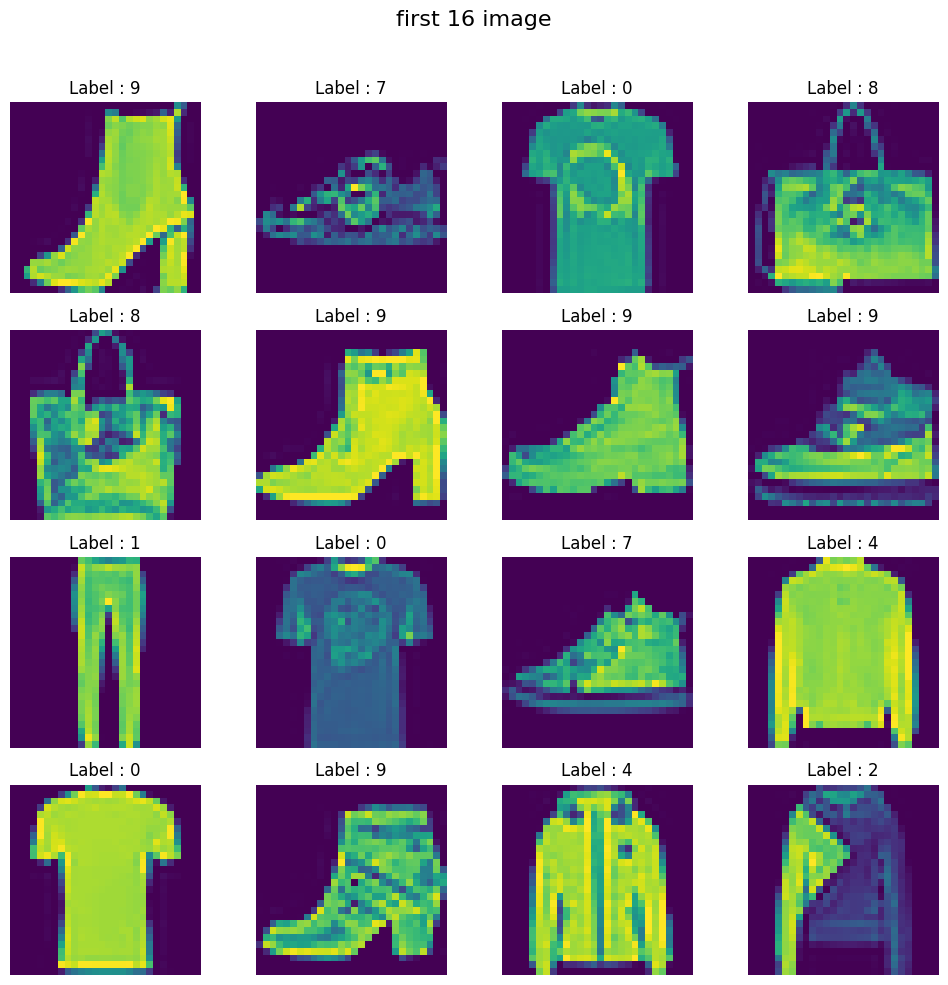

In [28]:
fig, axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle('first 16 image',fontsize=16)

for i, ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'Label : {df.iloc[i,0]}')

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [29]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [30]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2 ,random_state=42)
xtrain=xtrain/255.0
xtest=xtest/255.0


In [31]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features ,dtype=torch.float32)
    self.labels=torch.tensor(labels, dtype=torch.float32)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index] , self.labels[index]


In [32]:
train_dataset=CustomDataset(xtrain,ytrain)
test_dataset=CustomDataset(xtest,ytest)


In [33]:
train_dataset

In [41]:
train_loader=DataLoader(train_dataset , batch_size=32, shuffle=True, pin_memory=True )
test_loader=DataLoader(test_dataset , batch_size=32, shuffle=False, pin_memory=True)

print(len(train_loader))


150


In [35]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)

    )

  def forward(self,x):
    return self.model(x)

In [36]:
from torch.optim import optimizer
epochs=100
learning_rate=0.1
model=MyNN(xtrain.shape[1])
model.to(device)   #FOR GPU USE

criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(), lr=learning_rate)

In [37]:
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features,batch_labels in train_loader:
    #move data to gpu
    batch_features,batch_labels=batch_features.to(device) , batch_labels.to(device)


    #forward pass
    output=model(batch_features)

    #calculate loss
    loss=criterion(output,batch_labels.long())

    #back pass
    optimizer.zero_grad()
    loss.backward()

    #update grad
    optimizer.step()
    total_epoch_loss+=loss.item()

  total_epoch_loss/=len(train_loader)
  print(f'Epoch {epoch} ,Losss : {total_epoch_loss}')






Epoch 0 ,Losss : 1.3216368587811789
Epoch 1 ,Losss : 0.779336541891098
Epoch 2 ,Losss : 0.6427524608373641
Epoch 3 ,Losss : 0.5751657414436341
Epoch 4 ,Losss : 0.5278772541880608
Epoch 5 ,Losss : 0.49531100074450174
Epoch 6 ,Losss : 0.46192684868971506
Epoch 7 ,Losss : 0.4355265040695667
Epoch 8 ,Losss : 0.41890643616517387
Epoch 9 ,Losss : 0.39741520086924237
Epoch 10 ,Losss : 0.38665723502635957
Epoch 11 ,Losss : 0.37127780785163245
Epoch 12 ,Losss : 0.34902072985967
Epoch 13 ,Losss : 0.3476298343638579
Epoch 14 ,Losss : 0.315855147143205
Epoch 15 ,Losss : 0.31195787360270816
Epoch 16 ,Losss : 0.2958236853778362
Epoch 17 ,Losss : 0.2882651568452517
Epoch 18 ,Losss : 0.2712535865108172
Epoch 19 ,Losss : 0.2599384474754334
Epoch 20 ,Losss : 0.2577110414206982
Epoch 21 ,Losss : 0.24670669116079808
Epoch 22 ,Losss : 0.23920624203979968
Epoch 23 ,Losss : 0.22601549635330836
Epoch 24 ,Losss : 0.2235869560142358
Epoch 25 ,Losss : 0.21268803268671035
Epoch 26 ,Losss : 0.21945507449408372
Epo

In [38]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [39]:
total=0;
correct=0;
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features,batch_labels=batch_features.to(device) , batch_labels.to(device)
    outputs= model(batch_features)

    _,predicted=torch.max(outputs,1)
    total+=batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

  print(correct/total)

0.8241666666666667


In [40]:
#HOW TO USE GPU
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device : {device}')


Using Device : cuda
